In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 

cpi_data = pd.read_csv(r"data\historical_data_with_variables.csv", skiprows = 3)
epi14_data = pd.read_csv(r"data\2014-epi-scores.csv")
epi16_data = pd.read_csv(r"data\2016-epi-scores.csv")
epi18_data = pd.read_csv(r"data\2018-epi-scores.csv")
epi20_data = pd.read_csv(r"data\2020-epi-scores.csv")
epi22_data = pd.read_csv(r"data\2022-epi-scores.csv")
epi24_data = pd.read_csv(r"data\2024-epi-scores.csv")

In [108]:
cpi_data.head()

,Country / Territory,ISO3,Year,Region,CPI score,Rank,Standard error,Number of sources,Lower CI,Upper CI,...,Freedom House Nations in Transit,Global Insights Country Risk Ratings,IMD World Competitiveness Yearbook,PERC Asia Risk Guide,PRS International Country Risk Guide,Varieties of Democracy Project,World Bank CPIA,World Economic Forum EOS,World Justice Project Rule of Law Index,Transparency International Bribe Payers Survey
0,Afghanistan,AFG,2012,AP,8,174,3.30,3,2,13,...,NaN,1.0,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN
1,Afghanistan,AFG,2013,AP,8,175,3.30,3,3,13,...,NaN,1.0,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN
2,Afghanistan,AFG,2014,AP,12,172,1.29,4,10,14,...,NaN,11.0,NaN,NaN,NaN,NaN,12.0,NaN,16.0,NaN
3,Afghanistan,AFG,2015,AP,11,166,3.49,4,5,17,...,NaN,11.0,NaN,NaN,NaN,NaN,12.0,NaN,2.0,NaN
4,Afghanistan,AFG,2016,AP,15,169,1.74,5,12,17,...,NaN,10.0,NaN,NaN,NaN,16.0,13.0,NaN,13.0,NaN


In [109]:
epi14_data.columns

Index(['Rank', 'ISO3v10', 'Country', '2014 EPI Score',
       '10-Year Percent Change', 'Environmental Health', 'Ecosystem Vitality',
       'EH - Health Impacts', 'EH - Air Quality', 'EH -Water and Sanitation',
       'EV - Water Resources', 'EV - Agriculture', 'EV - Forests',
       'EV - Fisheries', 'EV- Biodiversity and Habitat',
       'EV - Climate and Energy', 'Child Mortality', 'Household Air Quality',
       'Air Pollution - Average Exposure to PM2.5',
       'Air Pollution - Average PM2.5 Exceedance', 'Access to Sanitation',
       'Access to Drinking Water', 'Wastewater Treatment',
       'Agricultural Subsidies', 'Pesticide Regulation',
       'Change in Forest Cover ', 'Fish Stocks',
       'Coastal Shelf Fishing Pressure',
       'Terrestrial Protected Areas (National Biome Weights)',
       'Terrestrial Protected Areas (Global Biome Weights)',
       'Marine Protected Areas', 'Critical Habitat Protection',
       'Trend in Carbon Intensity', 'Change of Trend in Carbon In

In [110]:
epi16_data.columns

Index(['Rank', 'Country', 'ISO3', '2016 EPI Score', '10-Year Percent Change',
       'Environmental Health', 'Ecosystem Vitality', 'EH - Health Impacts',
       'EH - Air Quality', 'EH - Water and Sanitation', 'EV - Water Resources',
       'EV - Agriculture', 'EV - Forests', 'EV - Fisheries',
       'EV - Biodiversity and Habitat', 'EV - Climate and Energy',
       'Environmental Risk Exposure', 'Household Air Quality',
       'Household Air Quality - Risk Exposure',
       'Air Pollution - Average Exposure to PM2.5',
       'Air Pollution - Average Exposure to PM2.5 - Risk Exposure',
       'Air Pollution - Average PM2.5 Exceedance',
       'Air Pollution - Average Exposure to NO2', 'Access to Sanitation',
       'Unsafe Sanitation- Risk Exposure', 'Access to Drinking Water',
       'Unsafe Drinking Water Quality -Risk Exposure', 'Wastewater Treatment',
       'Nitrogen Use Efficiency', 'Nitrogen Balance', 'Tree Cover Loss',
       'Fish Stocks', 'Terrestrial Protected Areas (Nationa

In [111]:
epi18_data.columns

Index(['code', 'iso', 'country', 'EPI.current', 'HLT.current', 'AIR.current',
       'H2O.current', 'HMT.current', 'ECO.current', 'BDH.current',
       'FOR.current', 'FSH.current', 'CCE.current', 'APE.current',
       'WRS.current', 'AGR.current', 'HAD.current', 'PME.current',
       'PMW.current', 'USD.current', 'UWD.current', 'PBD.current',
       'MPA.current', 'TBN.current', 'TBG.current', 'SPI.current',
       'PAR.current', 'SHI.current', 'TCL.current', 'FSS.current',
       'MTR.current', 'DCT.current', 'DPT.current', 'DMT.current',
       'DNT.current', 'DBT.current', 'DST.current', 'DXT.current',
       'WWT.current', 'SNM.current'],
      dtype='object')

In [112]:
epi20_data.columns

Index(['code', 'iso', 'country', 'EPI.new', 'HLT.new', 'AIR.new', 'PMD.new',
       'HAD.new', 'OZD.new', 'H2O.new',
       ...
       'LCB.rnk.new', 'GIB.rnk.new', 'GHP.rnk.new', 'APE.rnk.new',
       'SDA.rnk.new', 'NXA.rnk.new', 'AGR.rnk.new', 'SNM.rnk.new',
       'WRS.rnk.new', 'WWT.rnk.new'],
      dtype='object', length=141)

In [113]:
epi22_data.columns

Index(['code', 'iso', 'country', 'region', 'EPI.new', 'HLT.new', 'AIR.new',
       'HAD.new', 'PMD.new', 'OZD.new',
       ...
       'CCH.rnk.old', 'CDA.rnk.old', 'CHA.rnk.old', 'FGA.rnk.old',
       'NDA.rnk.old', 'BCA.rnk.old', 'GHN.rnk.old', 'LCB.rnk.old',
       'GIB.rnk.old', 'GHP.rnk.old'],
      dtype='object', length=279)

In [114]:
epi24_data.columns

Index(['code', 'iso', 'country', 'EPI.old', 'EPI.new', 'ECO.old', 'ECO.new',
       'BDH.old', 'BDH.new', 'MKP.old',
       ...
       'LUF.old', 'LUF.new', 'GTI.old', 'GTI.new', 'GTP.old', 'GTP.new',
       'GHN.old', 'GHN.new', 'CBP.old', 'CBP.new'],
      dtype='object', length=149)

EPI PROCESSING

In [115]:
# Create a new dataframe for each year with only the country and EPI score, and add a year column for comparison in final_df
# 2014
epi14 = epi14_data[['Country', '2014 EPI Score']].copy()
epi14.columns = ['Country', 'EPI_Score']
epi14['Year'] = 2014

# 2016
epi16 = epi16_data[['Country', '2016 EPI Score']].copy()
epi16.columns = ['Country', 'EPI_Score']
epi16['Year'] = 2016

# 2018
epi18 = epi18_data[['country', 'EPI.current']].copy()
epi18.columns = ['Country', 'EPI_Score']
epi18['Year'] = 2018

# 2020
epi20 = epi20_data[['country', 'EPI.new']].copy()
epi20.columns = ['Country', 'EPI_Score']
epi20['Year'] = 2020

# 2022 
epi22 = epi22_data[['country', 'EPI.new']].copy()
epi22.columns = ['Country', 'EPI_Score']
epi22['Year'] = 2022

# 2024 
epi24 = epi24_data[['country', 'EPI.new']].copy()
epi24.columns = ['Country', 'EPI_Score']
epi24['Year'] = 2024


In [116]:
# Merge all EPI dfs into single df
epi_dfs = pd.concat([epi14, epi16, epi18, epi20, epi22, epi24], ignore_index=True)
print(epi_dfs[epi_dfs['Country'] == 'United States of America'])

                       Country  EPI_Score  Year
32    United States of America      67.52  2014
203   United States of America      84.72  2016
530   United States of America      71.19  2018
708   United States of America      69.30  2020
888   United States of America      51.10  2022
1070  United States of America      57.20  2024


CPI PROCESSING

In [117]:
cpi_df = cpi_data.copy()
cpi_df.head()

,Country / Territory,ISO3,Year,Region,CPI score,Rank,Standard error,Number of sources,Lower CI,Upper CI,...,Freedom House Nations in Transit,Global Insights Country Risk Ratings,IMD World Competitiveness Yearbook,PERC Asia Risk Guide,PRS International Country Risk Guide,Varieties of Democracy Project,World Bank CPIA,World Economic Forum EOS,World Justice Project Rule of Law Index,Transparency International Bribe Payers Survey
0,Afghanistan,AFG,2012,AP,8,174,3.30,3,2,13,...,NaN,1.0,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN
1,Afghanistan,AFG,2013,AP,8,175,3.30,3,3,13,...,NaN,1.0,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN
2,Afghanistan,AFG,2014,AP,12,172,1.29,4,10,14,...,NaN,11.0,NaN,NaN,NaN,NaN,12.0,NaN,16.0,NaN
3,Afghanistan,AFG,2015,AP,11,166,3.49,4,5,17,...,NaN,11.0,NaN,NaN,NaN,NaN,12.0,NaN,2.0,NaN
4,Afghanistan,AFG,2016,AP,15,169,1.74,5,12,17,...,NaN,10.0,NaN,NaN,NaN,16.0,13.0,NaN,13.0,NaN


In [118]:
# Look at null percentages for each column in cpi_df to determine which variables to use
null_percentages = (cpi_df.isnull().sum() / len(cpi_df)) * 100
print(null_percentages)

Country / Territory                                     0.000000
ISO3                                                    0.000000
Year                                                    0.000000
Region                                                  0.000000
CPI score                                               0.000000
Rank                                                    0.000000
Standard error                                          0.000000
Number of sources                                       0.000000
Lower CI                                                0.000000
Upper CI                                                0.000000
African Development Bank CPIA                          76.182839
Bertelsmann Foundation Sustainable Governance Index    78.267843
Bertelsmann Foundation Transformation Index            25.380914
Economist Intelligence Unit Country Ratings            25.942261
Freedom House Nations in Transit                       83.720930
Global Insights Country R

In [119]:
# Drop all columns with more than 35% null values
columns_to_drop = null_percentages[null_percentages > 35].index
cpi_df = cpi_df.drop(columns=columns_to_drop , errors='ignore')


In [120]:
null_percentages_after_drop = (cpi_df.isnull().sum() / len(cpi_df)) * 100
print(null_percentages_after_drop)

Country / Territory                             0.000000
ISO3                                            0.000000
Year                                            0.000000
Region                                          0.000000
CPI score                                       0.000000
Rank                                            0.000000
Standard error                                  0.000000
Number of sources                               0.000000
Lower CI                                        0.000000
Upper CI                                        0.000000
Bertelsmann Foundation Transformation Index    25.380914
Economist Intelligence Unit Country Ratings    25.942261
Global Insights Country Risk Ratings            0.360866
PRS International Country Risk Guide           21.531676
Varieties of Democracy Project                 34.322374
World Economic Forum EOS                       26.864475
World Justice Project Rule of Law Index        33.279872
dtype: float64


In [121]:
cpi_df = cpi_df.rename(columns={'Country / Territory': 'Country'})

In [122]:
# Standardize all country names between each data frame
name_mapping = {
    'United States of America': 'United States',
    'Viet Nam': 'Vietnam',
    'Czech Republic': 'Czechia',
    'Dem. Rep. Congo': 'Democratic Republic of the Congo',
    'Republic of Congo': 'Congo, Republic of',
    'Turkiye': 'Turkey',
    'South Korea': 'Korea, South',
    'North Korea': 'Korea, North',
    # Encoding fixes for special characters
    "CÃƒÂ´te d'Ivoire": "Côte d'Ivoire",
    "SÃƒÂ£o TomÃƒÂ© and PrÃƒÂ\xadncipe": "Sao Tome and Principe"
}

# strip for standardizations
epi_dfs['Country'] = epi_dfs['Country'].str.strip()
cpi_df['Country'] = cpi_df['Country'].str.strip()

# apply dictionary
epi_dfs['Country'] = epi_dfs['Country'].replace(name_mapping)
cpi_df['Country'] = cpi_df['Country'].replace(name_mapping)



In [123]:
# Get unique lists of countries
cpi_list = set(cpi_df['Country'].unique())
epi_list = set(epi_dfs['Country'].unique())

# 1. Countries in EPI that are MISSING from CPI
missing_from_cpi = sorted(list(epi_list - cpi_list))
print(f"In EPI but not CPI: {missing_from_cpi}")

# 2. Countries in CPI that are MISSING from EPI
missing_from_epi = sorted(list(cpi_list - epi_list))
print(f"In CPI but not EPI: {missing_from_epi}")

In EPI but not CPI: ['Antigua and Barbuda', 'Cape Verde', 'Congo, Republic of', "Cote d'Ivoire", 'Kiribati', 'Kyrgyz Republic', 'Macedonia', 'Marshall Islands', 'Micronesia', 'Palau', 'Samoa', 'Swaziland', 'The Bahamas', 'The Gambia', 'Tonga']
In CPI but not EPI: ['Guinea Bissau', 'Hong Kong', 'Korea, North', 'Kosovo', 'Puerto Rico', 'South Sudan']


In [124]:
print(cpi_df['Country'].unique())

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Costa Rica' "Côte d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Czechia' 'Democratic Republic of the Congo' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji'
 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Grenada' 'Guatemala' 'Guinea' 'Guinea Bissau' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hong Kong' 'Hungary' 'Iceland' 'India' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan'
 'Kazakhstan' 'Kenya' 'K

In [125]:
print(epi_dfs['Country'].unique())

['Switzerland' 'Luxembourg' 'Australia' 'Singapore' 'Czechia' 'Germany'
 'Spain' 'Austria' 'Sweden' 'Norway' 'Netherlands' 'United Kingdom'
 'Denmark' 'Iceland' 'Slovenia' 'New Zealand' 'Portugal' 'Finland'
 'Ireland' 'Estonia' 'Slovakia' 'Italy' 'Greece' 'Canada'
 'United Arab Emirates' 'Japan' 'France' 'Hungary' 'Chile' 'Poland'
 'Serbia' 'Belarus' 'United States' 'Malta' 'Saudi Arabia' 'Belgium'
 'Brunei Darussalam' 'Cyprus' 'Israel' 'Latvia' 'Bulgaria' 'Kuwait'
 'Korea, South' 'Qatar' 'Croatia' 'Taiwan' 'Tonga' 'Armenia' 'Lithuania'
 'Egypt' 'Malaysia' 'Tunisia' 'Ecuador' 'Costa Rica' 'Jamaica' 'Mauritius'
 'Venezuela' 'Panama' 'Kiribati' 'Jordan' 'Seychelles' 'Montenegro'
 'Azerbaijan' 'Cuba' 'Mexico' 'Turkey' 'Albania' 'Syria' 'Sri Lanka'
 'Uruguay' 'Suriname' 'South Africa' 'Russia' 'Moldova'
 'Dominican Republic' 'Fiji' 'Brazil' 'Thailand' 'Trinidad and Tobago'
 'Palau' 'Morocco' 'Bahrain' 'Iran' 'Kazakhstan' 'Colombia' 'Romania'
 'Bolivia' 'Belize' 'Macedonia' 'Nicaragua' 'Leb

FINAL MERGE

In [126]:
final_df = pd.merge(epi_dfs, cpi_df, left_on=['Country', 'Year'], right_on=['Country', 'Year'], how='inner')
final_df.head()

,Country,EPI_Score,Year,ISO3,Region,CPI score,Rank,Standard error,Number of sources,Lower CI,Upper CI,Bertelsmann Foundation Transformation Index,Economist Intelligence Unit Country Ratings,Global Insights Country Risk Ratings,PRS International Country Risk Guide,Varieties of Democracy Project,World Economic Forum EOS,World Justice Project Rule of Law Index
0,Switzerland,87.67,2014,CHE,WE/EU,86,5,2.61,6,82,90,NaN,88.0,73.0,89.0,NaN,86.0,NaN
1,Luxembourg,83.29,2014,LUX,WE/EU,82,9,2.78,6,77,87,NaN,71.0,83.0,89.0,NaN,90.0,NaN
2,Australia,82.40,2014,AUS,AP,80,11,1.31,8,78,82,NaN,71.0,83.0,79.0,NaN,83.0,80.0
3,Singapore,81.78,2014,SGP,AP,84,7,1.75,8,81,87,75.0,88.0,83.0,79.0,NaN,90.0,84.0
4,Czechia,81.47,2014,CZE,WE/EU,51,53,2.94,9,46,56,62.0,54.0,63.0,41.0,NaN,48.0,53.0


In [127]:
# Drop columns that are irrelevant
columns_to_drop_final = ['ISO3', 'Rank', 'Number of sources']
final_df = final_df.drop(columns=columns_to_drop_final, errors='ignore')
final_df.head()

,Country,EPI_Score,Year,Region,CPI score,Standard error,Lower CI,Upper CI,Bertelsmann Foundation Transformation Index,Economist Intelligence Unit Country Ratings,Global Insights Country Risk Ratings,PRS International Country Risk Guide,Varieties of Democracy Project,World Economic Forum EOS,World Justice Project Rule of Law Index
0,Switzerland,87.67,2014,WE/EU,86,2.61,82,90,NaN,88.0,73.0,89.0,NaN,86.0,NaN
1,Luxembourg,83.29,2014,WE/EU,82,2.78,77,87,NaN,71.0,83.0,89.0,NaN,90.0,NaN
2,Australia,82.40,2014,AP,80,1.31,78,82,NaN,71.0,83.0,79.0,NaN,83.0,80.0
3,Singapore,81.78,2014,AP,84,1.75,81,87,75.0,88.0,83.0,79.0,NaN,90.0,84.0
4,Czechia,81.47,2014,WE/EU,51,2.94,46,56,62.0,54.0,63.0,41.0,NaN,48.0,53.0


Feature Preparation

In [128]:
# Seperate numerical values like indexes from "categorical" values like year and region
indices = [
    'CPI score', 
    'Bertelsmann Foundation Transformation Index', 
    'Economist Intelligence Unit Country Ratings', 
    'Global Insights Country Risk Ratings', 
    'PRS International Country Risk Guide', 
    'Varieties of Democracy Project',
    'World Economic Forum EOS',
    'World Justice Project Rule of Law Index'
]

# Select columns from final_df (keeping 'Region' for the groupby)
features = indices + ['Year', 'Region']
X = final_df[features].copy()
y = final_df['EPI_Score']

# Regional median imputation for every index, more accurate than global imputation as it accounts for geopolitical positions
for col in indices:
    X[col] = X[col].fillna(X.groupby('Region')[col].transform('median'))

# If a whole region is missing an index, fill with the global median
X[indices] = X[indices].fillna(X[indices].median())

# Encode the region column as numerical
X = pd.get_dummies(X, columns=['Region'], drop_first=True)

# Temporal split to account for data leakage (2014 isnt being compared to 2022)
X_train = X[X['Year'] < 2022]
y_train = y[X['Year'] < 2022]
X_test = X[X['Year'] >= 2022]
y_test = y[X['Year'] >= 2022]


Model 1 (Random Forest Regression)

In [129]:
# Grid Search for optimized hyperparameter tuning

# We define specific values we want the model to test
param_grid = {
    'n_estimators': [100, 300, 500],        # Number of trees
    'max_depth': [10, 20, None],           # Limits how complex each tree gets
    'min_samples_split': [2, 5, 10],       # Minimum data points needed to make a split
    'max_features': ['sqrt', 'log2', None] # Number of features to consider at each split
}

# Start grid search with five crossfolds
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the model and compare results
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R-Squared Score from CV: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best R-Squared Score from CV: 0.6116


In [ ]:
# Model performance metrics based on the best parameters found in previous cell
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"--- Final Model Performance ---")
print(f"R-squared: {r2:.4f}")
print(f"RMSE (Avg Error in EPI points): {rmse:.4f}")
print(f"MAE: {mae:.4f}")

--- Final Model Performance ---
R-squared: 0.4931
RMSE (Avg Error in EPI points): 8.7367
MAE: 6.9991


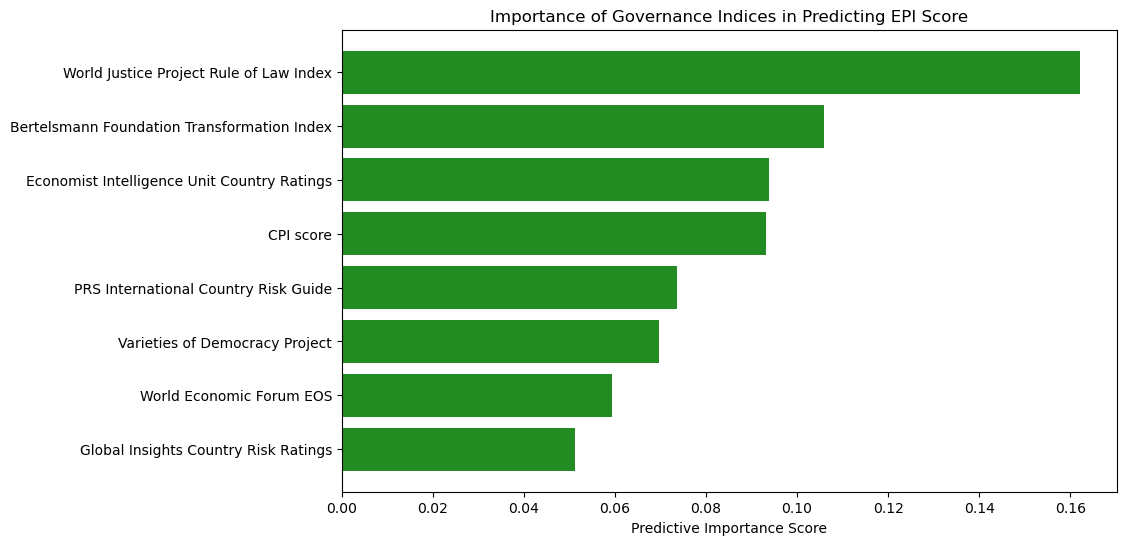

In [134]:
# Feature importance visualization 
importances = best_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Index': feature_names, 'Importance': importances})

# Seperate for only governance scores
gov_indices = [
    'CPI score', 'Bertelsmann Foundation Transformation Index', 
    'Economist Intelligence Unit Country Ratings', 'Global Insights Country Risk Ratings', 
    'PRS International Country Risk Guide', 'Varieties of Democracy Project',
    'World Economic Forum EOS', 'World Justice Project Rule of Law Index'
]
index_ranking = importance_df[importance_df['Index'].isin(gov_indices)].sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(index_ranking['Index'], index_ranking['Importance'], color='forestgreen')
plt.title("Importance of Governance Indices in Predicting EPI Score")
plt.xlabel("Predictive Importance Score")
plt.show()